In [56]:
import pandas as pd
import glob
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [45]:
dataframes = []
paths = glob.glob('/Users/connorhall/datasets/inst414/module 4 assignment/*.csv')
for csv in paths:
    df = pd.read_csv(csv)
    dataframes.append(df)
    
combined_df = pd.concat(dataframes, axis=0, ignore_index=True)


## verify output

In [ ]:
df_len = 0
for dataframe in dataframes:
    df_len += len(dataframe)
    
print(df_len)
print(len(combined_df))

348911
348911


In [53]:
combined_df

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202112,11,349,202112,11,350,165322,999750,TENNESSEE,47,2021,December,Tornado,C,165,SUMNER,OHX,11-DEC-21 03:49:00,CST-6,11-DEC-21 03:50:00,0,0,0,0,10.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,1.72,50.0,OHX,TN,189.0,WILSON,3.22,WNW,HUNTERS PT,2.52,NW,HUNTERS PT,36.3178,-86.3235,36.3296,-86.2965,One of the worst tornado outbreaks ever record...,This small EF-0 tornado was determined through...,CSV
1,202112,11,249,202112,11,254,165322,999613,TENNESSEE,47,2021,December,Tornado,C,43,DICKSON,OHX,11-DEC-21 02:49:00,CST-6,11-DEC-21 02:54:00,0,0,0,0,10.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF0,5.41,175.0,NaN,NaN,NaN,NaN,1.43,ENE,TIDWELL,2.11,ESE,BAKERSWORKS,36.0255,-87.3054,36.0736,-87.2330,One of the worst tornado outbreaks ever record...,This tornado developed just southeast of the D...,CSV
2,202112,11,325,202112,11,327,165322,999636,TENNESSEE,47,2021,December,Thunderstorm Wind,C,37,DAVIDSON,OHX,11-DEC-21 03:25:00,CST-6,11-DEC-21 03:27:00,0,0,0,0,250.00K,0.00K,NWS Storm Survey,74.00,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,NW,MAPLEWOOD,2.05,SW,AMQUI,36.2372,-86.7286,36.2572,-86.7035,One of the worst tornado outbreaks ever record...,Severe straight-line winds caused significant ...,CSV
3,202112,11,232,202112,11,239,165322,999604,TENNESSEE,47,2021,December,Tornado,C,81,HICKMAN,OHX,11-DEC-21 02:32:00,CST-6,11-DEC-21 02:39:00,0,0,0,0,50.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,8.54,400.0,NaN,NaN,NaN,NaN,3.67,NW,SPOT,3.92,NNW,PINEWOOD,35.9205,-87.6423,35.9725,-87.5068,One of the worst tornado outbreaks ever record...,This tornado touched down in far northwest Hic...,CSV
4,202112,6,724,202112,6,724,165321,999306,TENNESSEE,47,2021,December,Thunderstorm Wind,C,49,FENTRESS,OHX,06-DEC-21 07:24:00,CST-6,06-DEC-21 07:24:00,0,0,0,0,3.00K,0.00K,Social Media,52.00,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.15,W,JAMESTOWN,1.15,W,JAMESTOWN,36.4322,-84.9405,36.4322,-84.9405,After some isolated thunderstorms moved across...,A Facebook report indicated trees and power li...,CSV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348906,202509,16,1453,202509,16,1453,207582,1294668,NEBRASKA,31,2025,September,Hail,C,101,KEITH,LBF,16-SEP-25 14:53:00,MST-7,16-SEP-25 14:53:00,0,0,0,0,0.00K,0.00K,Public,1.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,N,ROSCOE,0.00,N,ROSCOE,41.1300,-101.5800,41.1300,-101.5800,"Thunderstorms developed around midday, along a...",Half dollar size hail reported on Interstate 8...,CSV
348907,202509,16,1454,202509,16,1454,207582,1294669,NEBRASKA,31,2025,September,Hail,C,101,KEITH,LBF,16-SEP-25 14:54:00,MST-7,16-SEP-25 14:54:00,0,0,0,0,0.00K,0.00K,Public,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.73,NW,SARBEN,1.73,NW,SARBEN,41.1900,-101.3400,41.1900,-101.3400,"Thunderstorms developed around midday, along a...",Public reports quarter sized hail along with t...,CSV
348908,202509,9,1658,202509,9,1658,207120,1294428,TEXAS,48,2025,September,Thunderstorm Wind,C,375,POTTER,AMA,09-SEP-25 16:58:00,CST-6,09-SEP-25 16:58:00,0,0,0,0,0.00K,0.00K,Mesonet,51.00,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.69,N,AMARILLO,9.69,N,AMARILLO,35.3400,-101.8100,35.3400,-101.8100,"On the evening of September 9th, a very subtle...",A 59mph wind gust was measured at the mesonet ...,CSV
34890

## calculate # of weather events per state

In [31]:
# count number of events per state
event_count = pd.crosstab(combined_df['STATE'], combined_df['EVENT_TYPE']).stack('EVENT_TYPE')
# get lists of states and events
states = event_count.index.get_level_values('STATE').tolist()
events = event_count.index.get_level_values('EVENT_TYPE').tolist()

events_df = pd.DataFrame({'State': states, 'Event': events})
# get list of # of events
events_df['Count'] = event_count.values
events_df

,State,Event,Count
0,ALABAMA,Astronomical Low Tide,1
1,ALABAMA,Avalanche,0
2,ALABAMA,Blizzard,0
3,ALABAMA,Coastal Flood,13
4,ALABAMA,Cold/Wind Chill,98
...,...,...,...
3721,WYOMING,Volcanic Ashfall,0
3722,WYOMING,Waterspout,0
3723,WYOMING,Wildfire,25
3724,WYOMING,Winter Storm,630


## create weather event count list for each state/location

In [36]:
unique_events = events_df['Event'].unique().tolist()
unique_states = events_df['State'].unique().tolist()

counts = []
for st in unique_states:
    st_filter = events_df[events_df['State'] == st]

    counts.append(st_filter['Count'].tolist())

In [37]:
# add count lists to dataframe
state_events = pd.DataFrame(counts, columns=unique_events, index=unique_states)
pd.options.display.max_columns = None
state_events

,Astronomical Low Tide,Avalanche,Blizzard,Coastal Flood,Cold/Wind Chill,Debris Flow,Dense Fog,Dense Smoke,Drought,Dust Devil,Dust Storm,Excessive Heat,Extreme Cold/Wind Chill,Flash Flood,Flood,Freezing Fog,Frost/Freeze,Funnel Cloud,Hail,Heat,Heavy Rain,Heavy Snow,High Surf,High Wind,Hurricane (Typhoon),Ice Storm,Lake-Effect Snow,Lakeshore Flood,Lightning,Marine Dense Fog,Marine Hail,Marine High Wind,Marine Hurricane/Typhoon,Marine Lightning,Marine Strong Wind,Marine Thunderstorm Wind,Marine Tropical Depression,Marine Tropical Storm,Rip Current,Seiche,Sleet,Sneakerwave,Storm Surge/Tide,Strong Wind,Thunderstorm Wind,Tornado,Tropical Depression,Tropical Storm,Tsunami,Volcanic Ashfall,Waterspout,Wildfire,Winter Storm,Winter Weather
ALABAMA,1,0,0,13,98,0,0,0,392,0,0,194,16,540,59,1,190,7,739,342,35,68,0,17,0,7,0,0,47,0,0,0,0,0,0,0,0,0,11,0,6,0,8,142,4348,485,6,17,0,0,0,0,52,75
ALASKA,1,8,288,40,16,9,0,0,0,0,0,0,17,2,123,0,18,1,3,0,1,273,0,335,0,11,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,5,5,1,0,0,2,2,0,21,223,158
AMERICAN SAMOA,0,0,0,3,0,0,0,0,1,0,0,0,0,52,10,0,0,1,0,3,44,0,13,22,0,0,0,0,2,0,0,0,0,0,0,0,0,0,3,0,0,0,0,15,10,0,0,0,6,0,0,0,0,0
ARIZONA,0,3,0,0,29,12,25,0,252,4,272,841,3,1270,130,0,2,23,203,502,40,196,0,301,0,1,0,0,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,960,35,0,0,0,0,0,97,27,20
ARKANSAS,0,0,0,0,64,0,0,0,198,0,0,412,11,516,461,1,0,15,1156,808,138,134,0,13,0,57,0,0,15,0,0,0,0,0,0,0,0,0,0,0,3,0,0,18,1571,253,1,0,0,0,0,0,421,374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGINIA,6,2,2,192,91,10,98,0,76,0,0,112,25,1185,648,0,39,23,531,40,472,98,0,223,0,63,0,0,75,0,0,0,0,0,0,0,0,0,3,0,0,0,0,88,4556,56,0,27,0,0,0,4,588,937
WASHINGTON,1,7,5,18,22,22,0,0,0,0,13,76,3,32,99,2,50,9,32,123,33,441,3,201,0,34,0,0,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,48,88,11,0,0,1,0,0,126,68,125
WEST VIRGINIA,2,0,17,0,89,12,36,0,302,0,0,10,27,631,628,0,9,6,298,12,30,313,0,177,0,35,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,335,2225,27,0,0,0,0,0,1,349,1095
WISCONSIN,0,0,7,0,148,1,6,0,358,0,0,128,192,122,179,0,1,21,1411,45,53,317,3,65,0,44,4,1,16,0,0,0,0,0,0,0,0,0,9,2,0,0,0,42,1535,198,0,0,0,0,0,6,614,984


## verify output

In [44]:
state_selection = 'ALASKA'
# search original dataframe
combined_df[combined_df['STATE'] == state_selection]['EVENT_TYPE'].value_counts().sort_index()

EVENT_TYPE
Astronomical Low Tide        1
Avalanche                    8
Blizzard                   288
Coastal Flood               40
Cold/Wind Chill             16
Debris Flow                  9
Extreme Cold/Wind Chill     17
Flash Flood                  2
Flood                      123
Frost/Freeze                18
Funnel Cloud                 1
Hail                         3
Heavy Rain                   1
Heavy Snow                 273
High Wind                  335
Ice Storm                   11
Lightning                    1
Storm Surge/Tide             2
Strong Wind                  5
Thunderstorm Wind            5
Tornado                      1
Tsunami                      2
Volcanic Ashfall             2
Wildfire                    21
Winter Storm               223
Winter Weather             158
Name: count, dtype: int64

## identify ideal k value

In [60]:
intertia_values = []
for k in range(2, 20):
    cluster_model = KMeans(n_clusters=k)
    cluster_model.fit(state_events)
    intertia_values.append(cluster_model.inertia_)

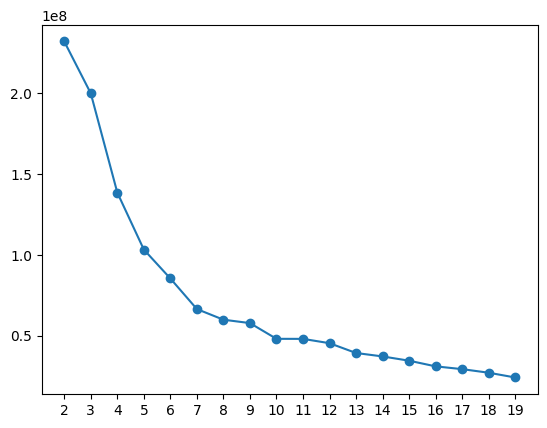

In [61]:
plt.plot(range(2, 20), intertia_values, marker='o')
plt.xticks(range(2, 20))
plt.show()

## create clusters

In [62]:
cluster_model = KMeans(n_clusters=9)
state_events['cluster'] = cluster_model.fit_predict(state_events)


In [63]:
state_events['cluster'].value_counts()

cluster
1    32
0    11
6     6
8     6
2     6
4     3
7     3
3     1
5     1
Name: count, dtype: int64

## sample states in each cluster

In [84]:
# top 5 clusters
print(state_events[state_events['cluster'].astype('str').isin(['1', '0', '6', '8', '2'])]\
    [['cluster']].groupby('cluster').sample(5))

                cluster
FLORIDA               0
SOUTH CAROLINA        0
OHIO                  0
TENNESSEE             0
INDIANA               0
LAKE MICHIGAN         1
GUAM WATERS           1
RHODE ISLAND          1
HAWAII                1
LAKE ONTARIO          1
KANSAS                2
MISSOURI              2
IOWA                  2
SOUTH DAKOTA          2
NEBRASKA              2
NEW YORK              6
ILLINOIS              6
ALABAMA               6
GEORGIA               6
PENNSYLVANIA          6
WISCONSIN             8
ARKANSAS              8
MICHIGAN              8
MINNESOTA             8
NORTH DAKOTA          8


In [85]:
# remaining clusters
print(state_events[state_events['cluster'].astype('str').isin(['4', '7', '3', '5'])][['cluster']])

                cluster
ATLANTIC NORTH        4
ATLANTIC SOUTH        4
CALIFORNIA            3
GULF OF MEXICO        4
MONTANA               7
NEW MEXICO            7
TEXAS                 5
WYOMING               7
